In [1]:
from google.colab import drive
drive.mount('/content/drive')

!apt-get install openslide-tools
!pip install openslide-python==1.3.1
import glob
import math
import matplotlib.pyplot as plt
import multiprocessing
import numpy as np

import openslide
from openslide import OpenSlideError
import os
import PIL
from PIL import Image
import re
import sys


import datetime
import numpy as np
from PIL import Image, ImageDraw, ImageFont

#filter_rgb_to_grayscale(rgb)
import math
import multiprocessing
import numpy as np
import os
import scipy.ndimage.morphology as sc_morph
import skimage.color as sk_color
import skimage.exposure as sk_exposure
import skimage.feature as sk_feature
import skimage.filters as sk_filters
import skimage.future as sk_future
import skimage.morphology as sk_morphology
import skimage.segmentation as sk_segmentation


BASE_DIR = os.path.join(".", "data")
# BASE_DIR = os.path.join(os.sep, "Volumes", "BigData", "TUPAC")
TRAIN_PREFIX = "TUPAC-TR-"
SRC_TRAIN_DIR = os.path.join(BASE_DIR, "training_slides")
SRC_TRAIN_EXT = "svs"
DEST_TRAIN_SUFFIX = ""  # Example: "train-"
DEST_TRAIN_EXT = "png"
SCALE_FACTOR = 32
DEST_TRAIN_DIR = os.path.join(BASE_DIR, "training_" + DEST_TRAIN_EXT)
THUMBNAIL_SIZE = 300
THUMBNAIL_EXT = "jpg"

DEST_TRAIN_THUMBNAIL_DIR = os.path.join(BASE_DIR, "training_thumbnail_" + THUMBNAIL_EXT)

FILTER_SUFFIX = ""  # Example: "filter-"
FILTER_RESULT_TEXT = "filtered"
FILTER_DIR = os.path.join(BASE_DIR, "filter_" + DEST_TRAIN_EXT)
FILTER_THUMBNAIL_DIR = os.path.join(BASE_DIR, "filter_thumbnail_" + THUMBNAIL_EXT)
FILTER_PAGINATION_SIZE = 50
FILTER_PAGINATE = True
FILTER_HTML_DIR = BASE_DIR

TILE_SUMMARY_DIR = os.path.join(BASE_DIR, "tile_summary_" + DEST_TRAIN_EXT)
TILE_SUMMARY_ON_ORIGINAL_DIR = os.path.join(BASE_DIR, "tile_summary_on_original_" + DEST_TRAIN_EXT)
TILE_SUMMARY_SUFFIX = "tile_summary"
TILE_SUMMARY_THUMBNAIL_DIR = os.path.join(BASE_DIR, "tile_summary_thumbnail_" + THUMBNAIL_EXT)
TILE_SUMMARY_ON_ORIGINAL_THUMBNAIL_DIR = os.path.join(BASE_DIR, "tile_summary_on_original_thumbnail_" + THUMBNAIL_EXT)
TILE_SUMMARY_PAGINATION_SIZE = 50
TILE_SUMMARY_PAGINATE = True
TILE_SUMMARY_HTML_DIR = BASE_DIR

TILE_DATA_DIR = os.path.join(BASE_DIR, "tile_data")
TILE_DATA_SUFFIX = "tile_data"

TOP_TILES_SUFFIX = "top_tile_summary"
TOP_TILES_DIR = os.path.join(BASE_DIR, TOP_TILES_SUFFIX + "_" + DEST_TRAIN_EXT)
TOP_TILES_THUMBNAIL_DIR = os.path.join(BASE_DIR, TOP_TILES_SUFFIX + "_thumbnail_" + THUMBNAIL_EXT)
TOP_TILES_ON_ORIGINAL_DIR = os.path.join(BASE_DIR, TOP_TILES_SUFFIX + "_on_original_" + DEST_TRAIN_EXT)
TOP_TILES_ON_ORIGINAL_THUMBNAIL_DIR = os.path.join(BASE_DIR,
                                                   TOP_TILES_SUFFIX + "_on_original_thumbnail_" + THUMBNAIL_EXT)

TILE_DIR = os.path.join(BASE_DIR, "tiles_" + DEST_TRAIN_EXT)
TILE_SUFFIX = "tile"

STATS_DIR = os.path.join(BASE_DIR, "svs_stats")

###--- Util functions



# If True, display additional NumPy array stats (min, max, mean, is_binary).
ADDITIONAL_NP_STATS = False

apply_image_filters

def pil_to_np_rgb(pil_img):
  """
  Convert a PIL Image to a NumPy array.

  Note that RGB PIL (w, h) -> NumPy (h, w, 3).

  Args:
    pil_img: The PIL Image.

  Returns:
    The PIL image converted to a NumPy array.
  """

  rgb = np.asarray(pil_img)
  np_info(rgb, "RGB")
  return rgb


def np_to_pil(np_img):
  """
  Convert a NumPy array to a PIL Image.

  Args:
    np_img: The image represented as a NumPy array.

  Returns:
     The NumPy array converted to a PIL Image.
  """
  if np_img.dtype == "bool":
    np_img = np_img.astype("uint8") * 255
  elif np_img.dtype == "float64":
    np_img = (np_img * 255).astype("uint8")
  return Image.fromarray(np_img)


def np_info(np_arr, name=None):
  """
  Display information (shape, type, max, min, etc) about a NumPy array.

  Args:
    np_arr: The NumPy array.
    name: The (optional) name of the array.
    elapsed: The (optional) time elapsed to perform a filtering operation.
  """

  if name is None:
    name = "NumPy Array"


  if ADDITIONAL_NP_STATS is False:
    print("%-20s | Type: %-7s Shape: %s" % (name,np_arr.dtype, np_arr.shape))
  else:
    # np_arr = np.asarray(np_arr)
    max = np_arr.max()
    min = np_arr.min()
    mean = np_arr.mean()
    is_binary = "T" if (np.unique(np_arr).size == 2) else "F"
    print("%-20s | Min: %6.2f  Max: %6.2f  Mean: %6.2f  Binary: %s  Type: %-7s Shape: %s" % (name, min, max, mean, is_binary, np_arr.dtype, np_arr.shape))


def display_img(np_img, text=None, font_path="/Library/Fonts/Arial Bold.ttf", size=48, color=(255, 0, 0), background=(255, 255, 255), border=(0, 0, 0), bg=False):
  """
  Convert a NumPy array to a PIL image, add text to the image, and display the image.

  Args:
    np_img: Image as a NumPy array.
    text: The text to add to the image.
    font_path: The path to the font to use.
    size: The font size
    color: The font color
    background: The background color
    border: The border color
    bg: If True, add rectangle background behind text
  """
  result = np_to_pil(np_img)
  # if gray, convert to RGB for display
  if result.mode == 'L':
    result = result.convert('RGB')
  draw = ImageDraw.Draw(result)
  if text is not None:
    font = ImageFont.truetype(font_path, size)
    if bg:
      (x, y) = draw.textsize(text, font)
      draw.rectangle([(0, 0), (x + 5, y + 4)], fill=background, outline=border)
    draw.text((2, 0), text, color, font=font)
  result.show()


def mask_rgb(rgb, mask):
  """
  Apply a binary (T/F, 1/0) mask to a 3-channel RGB image and output the result.

  Args:
    rgb: RGB image as a NumPy array.
    mask: An image mask to determine which pixels in the original image should be displayed.

  Returns:
    NumPy array representing an RGB image with mask applied.
  """

  result = rgb * np.dstack([mask, mask, mask])
  np_info(result, "Mask RGB")
  return result




###---Slide functions
def open_slide(filename):
  """
  Open a whole-slide image (*.svs, etc).

  Args:
    filename: Name of the slide file.

  Returns:
    An OpenSlide object representing a whole-slide image.
  """
  try:
    slide = openslide.open_slide(filename)
  except OpenSlideError:
    slide = None
  except FileNotFoundError:
    slide = None
  return slide


def open_image(filename):
  """
  Open an image (*.jpg, *.png, etc).

  Args:
    filename: Name of the image file.

  returns:
    A PIL.Image.Image object representing an image.
  """
  image = Image.open(filename)
  return image


def open_image_np(filename):
  """
  Open an image (*.jpg, *.png, etc) as an RGB NumPy array.

  Args:
    filename: Name of the image file.

  returns:
    A NumPy representing an RGB image.
  """
  pil_img = open_image(filename)
  np_img = pil_to_np_rgb(pil_img)
  return np_img


def get_training_slide_path(slide_number):
  """
  Convert slide number to a path to the corresponding WSI training slide file.

  Example:
    5 -> ../data/training_slides/TUPAC-TR-005.svs

  Args:
    slide_number: The slide number.

  Returns:
    Path to the WSI training slide file.
  """
  padded_sl_num = str(slide_number).zfill(3)
  slide_filepath = os.path.join(SRC_TRAIN_DIR, TRAIN_PREFIX + padded_sl_num + "." + SRC_TRAIN_EXT)
  return slide_filepath


def get_tile_image_path(tile):
  """
  Obtain tile image path based on tile information such as row, column, row pixel position, column pixel position,
  pixel width, and pixel height.

  Args:
    tile: Tile object.

  Returns:
    Path to image tile.
  """
  t = tile
  padded_sl_num = str(t.slide_num).zfill(3)
  tile_path = os.path.join(TILE_DIR, padded_sl_num,
                           TRAIN_PREFIX + padded_sl_num + "-" + TILE_SUFFIX + "-r%d-c%d-x%d-y%d-w%d-h%d" % (
                             t.r, t.c, t.o_c_s, t.o_r_s, t.o_c_e - t.o_c_s, t.o_r_e - t.o_r_s) + "." + DEST_TRAIN_EXT)
  return tile_path


def get_tile_image_path_by_slide_row_col(slide_number, row, col):
  """
  Obtain tile image path using wildcard lookup with slide number, row, and column.

  Args:
    slide_number: The slide number.
    row: The row.
    col: The column.

  Returns:
    Path to image tile.
  """
  padded_sl_num = str(slide_number).zfill(3)
  wilcard_path = os.path.join(TILE_DIR, padded_sl_num,
                              TRAIN_PREFIX + padded_sl_num + "-" + TILE_SUFFIX + "-r%d-c%d-*." % (
                                row, col) + DEST_TRAIN_EXT)
  img_path = glob.glob(wilcard_path)[0]
  return img_path


def get_training_image_path(slide_number, large_w=None, large_h=None, small_w=None, small_h=None):
  """
  Convert slide number and optional dimensions to a training image path. If no dimensions are supplied,
  the corresponding file based on the slide number will be looked up in the file system using a wildcard.

  Example:
    5 -> ../data/training_png/TUPAC-TR-005-32x-49920x108288-1560x3384.png

  Args:
    slide_number: The slide number.
    large_w: Large image width.
    large_h: Large image height.
    small_w: Small image width.
    small_h: Small image height.

  Returns:
     Path to the image file.
  """
  padded_sl_num = str(slide_number).zfill(3)
  if large_w is None and large_h is None and small_w is None and small_h is None:
    wildcard_path = os.path.join(DEST_TRAIN_DIR, TRAIN_PREFIX + padded_sl_num + "*." + DEST_TRAIN_EXT)
    img_path = glob.glob(wildcard_path)[0]
  else:
    img_path = os.path.join(DEST_TRAIN_DIR, TRAIN_PREFIX + padded_sl_num + "-" + str(
      SCALE_FACTOR) + "x-" + DEST_TRAIN_SUFFIX + str(
      large_w) + "x" + str(large_h) + "-" + str(small_w) + "x" + str(small_h) + "." + DEST_TRAIN_EXT)
  return img_path


def get_training_thumbnail_path(slide_number, large_w=None, large_h=None, small_w=None, small_h=None):
  """
  Convert slide number and optional dimensions to a training thumbnail path. If no dimensions are
  supplied, the corresponding file based on the slide number will be looked up in the file system using a wildcard.

  Example:
    5 -> ../data/training_thumbnail_jpg/TUPAC-TR-005-32x-49920x108288-1560x3384.jpg

  Args:
    slide_number: The slide number.
    large_w: Large image width.
    large_h: Large image height.
    small_w: Small image width.
    small_h: Small image height.

  Returns:
     Path to the thumbnail file.
  """
  padded_sl_num = str(slide_number).zfill(3)
  if large_w is None and large_h is None and small_w is None and small_h is None:
    wilcard_path = os.path.join(DEST_TRAIN_THUMBNAIL_DIR, TRAIN_PREFIX + padded_sl_num + "*." + THUMBNAIL_EXT)
    img_path = glob.glob(wilcard_path)[0]
  else:
    img_path = os.path.join(DEST_TRAIN_THUMBNAIL_DIR, TRAIN_PREFIX + padded_sl_num + "-" + str(
      SCALE_FACTOR) + "x-" + DEST_TRAIN_SUFFIX + str(
      large_w) + "x" + str(large_h) + "-" + str(small_w) + "x" + str(small_h) + "." + THUMBNAIL_EXT)
  return img_path


def get_filter_image_path(slide_number, filter_number, filter_name_info):
  """
  Convert slide number, filter number, and text to a path to a filter image file.

  Example:
    5, 1, "rgb" -> ../data/filter_png/TUPAC-TR-005-001-rgb.png

  Args:
    slide_number: The slide number.
    filter_number: The filter number.
    filter_name_info: Descriptive text describing filter.

  Returns:
    Path to the filter image file.
  """
  dir = FILTER_DIR
  if not os.path.exists(dir):
    os.makedirs(dir)
  img_path = os.path.join(dir, get_filter_image_filename(slide_number, filter_number, filter_name_info))
  return img_path


def get_filter_thumbnail_path(slide_number, filter_number, filter_name_info):
  """
  Convert slide number, filter number, and text to a path to a filter thumbnail file.

  Example:
    5, 1, "rgb" -> ../data/filter_thumbnail_jpg/TUPAC-TR-005-001-rgb.jpg

  Args:
    slide_number: The slide number.
    filter_number: The filter number.
    filter_name_info: Descriptive text describing filter.

  Returns:
    Path to the filter thumbnail file.
  """
  dir = FILTER_THUMBNAIL_DIR
  if not os.path.exists(dir):
    os.makedirs(dir)
  img_path = os.path.join(dir, get_filter_image_filename(slide_number, filter_number, filter_name_info, thumbnail=True))
  return img_path


def get_filter_image_filename(slide_number, filter_number, filter_name_info, thumbnail=False):
  """
  Convert slide number, filter number, and text to a filter file name.

  Example:
    5, 1, "rgb", False -> TUPAC-TR-005-001-rgb.png
    5, 1, "rgb", True -> TUPAC-TR-005-001-rgb.jpg

  Args:
    slide_number: The slide number.
    filter_number: The filter number.
    filter_name_info: Descriptive text describing filter.
    thumbnail: If True, produce thumbnail filename.

  Returns:
    The filter image or thumbnail file name.
  """
  if thumbnail:
    ext = THUMBNAIL_EXT
  else:
    ext = DEST_TRAIN_EXT
  padded_sl_num = str(slide_number).zfill(3)
  padded_fi_num = str(filter_number).zfill(3)
  img_filename = TRAIN_PREFIX + padded_sl_num + "-" + padded_fi_num + "-" + FILTER_SUFFIX + filter_name_info + "." + ext
  return img_filename


def get_tile_summary_image_path(slide_number):
  """
  Convert slide number to a path to a tile summary image file.

  Example:
    5 -> ../data/tile_summary_png/TUPAC-TR-005-tile_summary.png

  Args:
    slide_number: The slide number.

  Returns:
    Path to the tile summary image file.
  """
  if not os.path.exists(TILE_SUMMARY_DIR):
    os.makedirs(TILE_SUMMARY_DIR)
  img_path = os.path.join(TILE_SUMMARY_DIR, get_tile_summary_image_filename(slide_number))
  return img_path


def get_tile_summary_thumbnail_path(slide_number):
  """
  Convert slide number to a path to a tile summary thumbnail file.

  Example:
    5 -> ../data/tile_summary_thumbnail_jpg/TUPAC-TR-005-tile_summary.jpg

  Args:
    slide_number: The slide number.

  Returns:
    Path to the tile summary thumbnail file.
  """
  if not os.path.exists(TILE_SUMMARY_THUMBNAIL_DIR):
    os.makedirs(TILE_SUMMARY_THUMBNAIL_DIR)
  img_path = os.path.join(TILE_SUMMARY_THUMBNAIL_DIR, get_tile_summary_image_filename(slide_number, thumbnail=True))
  return img_path


def get_tile_summary_on_original_image_path(slide_number):
  """
  Convert slide number to a path to a tile summary on original image file.

  Example:
    5 -> ../data/tile_summary_on_original_png/TUPAC-TR-005-tile_summary.png

  Args:
    slide_number: The slide number.

  Returns:
    Path to the tile summary on original image file.
  """
  if not os.path.exists(TILE_SUMMARY_ON_ORIGINAL_DIR):
    os.makedirs(TILE_SUMMARY_ON_ORIGINAL_DIR)
  img_path = os.path.join(TILE_SUMMARY_ON_ORIGINAL_DIR, get_tile_summary_image_filename(slide_number))
  return img_path


def get_tile_summary_on_original_thumbnail_path(slide_number):
  """
  Convert slide number to a path to a tile summary on original thumbnail file.

  Example:
    5 -> ../data/tile_summary_on_original_thumbnail_jpg/TUPAC-TR-005-tile_summary.jpg

  Args:
    slide_number: The slide number.

  Returns:
    Path to the tile summary on original thumbnail file.
  """
  if not os.path.exists(TILE_SUMMARY_ON_ORIGINAL_THUMBNAIL_DIR):
    os.makedirs(TILE_SUMMARY_ON_ORIGINAL_THUMBNAIL_DIR)
  img_path = os.path.join(TILE_SUMMARY_ON_ORIGINAL_THUMBNAIL_DIR,
                          get_tile_summary_image_filename(slide_number, thumbnail=True))
  return img_path


def get_top_tiles_on_original_image_path(slide_number):
  """
  Convert slide number to a path to a top tiles on original image file.

  Example:
    5 -> ../data/top_tiles_on_original_png/TUPAC-TR-005-32x-49920x108288-1560x3384-top_tiles.png

  Args:
    slide_number: The slide number.

  Returns:
    Path to the top tiles on original image file.
  """
  if not os.path.exists(TOP_TILES_ON_ORIGINAL_DIR):
    os.makedirs(TOP_TILES_ON_ORIGINAL_DIR)
  img_path = os.path.join(TOP_TILES_ON_ORIGINAL_DIR, get_top_tiles_image_filename(slide_number))
  return img_path


def get_top_tiles_on_original_thumbnail_path(slide_number):
  """
  Convert slide number to a path to a top tiles on original thumbnail file.

  Example:
    5 -> ../data/top_tiles_on_original_thumbnail_jpg/TUPAC-TR-005-32x-49920x108288-1560x3384-top_tiles.jpg

  Args:
    slide_number: The slide number.

  Returns:
    Path to the top tiles on original thumbnail file.
  """
  if not os.path.exists(TOP_TILES_ON_ORIGINAL_THUMBNAIL_DIR):
    os.makedirs(TOP_TILES_ON_ORIGINAL_THUMBNAIL_DIR)
  img_path = os.path.join(TOP_TILES_ON_ORIGINAL_THUMBNAIL_DIR,
                          get_top_tiles_image_filename(slide_number, thumbnail=True))
  return img_path


def get_tile_summary_image_filename(slide_number, thumbnail=False):
  """
  Convert slide number to a tile summary image file name.

  Example:
    5, False -> TUPAC-TR-005-tile_summary.png
    5, True -> TUPAC-TR-005-tile_summary.jpg

  Args:
    slide_number: The slide number.
    thumbnail: If True, produce thumbnail filename.

  Returns:
    The tile summary image file name.
  """
  if thumbnail:
    ext = THUMBNAIL_EXT
  else:
    ext = DEST_TRAIN_EXT
  padded_sl_num = str(slide_number).zfill(3)

  training_img_path = get_training_image_path(slide_number)
  large_w, large_h, small_w, small_h = parse_dimensions_from_image_filename(training_img_path)
  img_filename = TRAIN_PREFIX + padded_sl_num + "-" + str(SCALE_FACTOR) + "x-" + str(large_w) + "x" + str(
    large_h) + "-" + str(small_w) + "x" + str(small_h) + "-" + TILE_SUMMARY_SUFFIX + "." + ext

  return img_filename


def get_top_tiles_image_filename(slide_number, thumbnail=False):
  """
  Convert slide number to a top tiles image file name.

  Example:
    5, False -> TUPAC-TR-005-32x-49920x108288-1560x3384-top_tiles.png
    5, True -> TUPAC-TR-005-32x-49920x108288-1560x3384-top_tiles.jpg

  Args:
    slide_number: The slide number.
    thumbnail: If True, produce thumbnail filename.

  Returns:
    The top tiles image file name.
  """
  if thumbnail:
    ext = THUMBNAIL_EXT
  else:
    ext = DEST_TRAIN_EXT
  padded_sl_num = str(slide_number).zfill(3)

  training_img_path = get_training_image_path(slide_number)
  large_w, large_h, small_w, small_h = parse_dimensions_from_image_filename(training_img_path)
  img_filename = TRAIN_PREFIX + padded_sl_num + "-" + str(SCALE_FACTOR) + "x-" + str(large_w) + "x" + str(
    large_h) + "-" + str(small_w) + "x" + str(small_h) + "-" + TOP_TILES_SUFFIX + "." + ext

  return img_filename


def get_top_tiles_image_path(slide_number):
  """
  Convert slide number to a path to a top tiles image file.

  Example:
    5 -> ../data/top_tiles_png/TUPAC-TR-005-32x-49920x108288-1560x3384-top_tiles.png

  Args:
    slide_number: The slide number.

  Returns:
    Path to the top tiles image file.
  """
  if not os.path.exists(TOP_TILES_DIR):
    os.makedirs(TOP_TILES_DIR)
  img_path = os.path.join(TOP_TILES_DIR, get_top_tiles_image_filename(slide_number))
  return img_path


def get_top_tiles_thumbnail_path(slide_number):
  """
  Convert slide number to a path to a tile summary thumbnail file.

  Example:
    5 -> ../data/top_tiles_thumbnail_jpg/TUPAC-TR-005-32x-49920x108288-1560x3384-top_tiles.jpg
  Args:
    slide_number: The slide number.

  Returns:
    Path to the top tiles thumbnail file.
  """
  if not os.path.exists(TOP_TILES_THUMBNAIL_DIR):
    os.makedirs(TOP_TILES_THUMBNAIL_DIR)
  img_path = os.path.join(TOP_TILES_THUMBNAIL_DIR, get_top_tiles_image_filename(slide_number, thumbnail=True))
  return img_path


def get_tile_data_filename(slide_number):
  """
  Convert slide number to a tile data file name.

  Example:
    5 -> TUPAC-TR-005-32x-49920x108288-1560x3384-tile_data.csv

  Args:
    slide_number: The slide number.

  Returns:
    The tile data file name.
  """
  padded_sl_num = str(slide_number).zfill(3)

  training_img_path = get_training_image_path(slide_number)
  large_w, large_h, small_w, small_h = parse_dimensions_from_image_filename(training_img_path)
  data_filename = TRAIN_PREFIX + padded_sl_num + "-" + str(SCALE_FACTOR) + "x-" + str(large_w) + "x" + str(
    large_h) + "-" + str(small_w) + "x" + str(small_h) + "-" + TILE_DATA_SUFFIX + ".csv"

  return data_filename


def get_tile_data_path(slide_number):
  """
  Convert slide number to a path to a tile data file.

  Example:
    5 -> ../data/tile_data/TUPAC-TR-005-32x-49920x108288-1560x3384-tile_data.csv

  Args:
    slide_number: The slide number.

  Returns:
    Path to the tile data file.
  """
  if not os.path.exists(TILE_DATA_DIR):
    os.makedirs(TILE_DATA_DIR)
  file_path = os.path.join(TILE_DATA_DIR, get_tile_data_filename(slide_number))
  return file_path


def get_filter_image_result(slide_number):
  """
  Convert slide number to the path to the file that is the final result of filtering.

  Example:
    5 -> ../data/filter_png/TUPAC-TR-005-32x-49920x108288-1560x3384-filtered.png

  Args:
    slide_number: The slide number.

  Returns:
    Path to the filter image file.
  """
  padded_sl_num = str(slide_number).zfill(3)
  training_img_path = get_training_image_path(slide_number)
  large_w, large_h, small_w, small_h = parse_dimensions_from_image_filename(training_img_path)
  img_path = os.path.join(FILTER_DIR, TRAIN_PREFIX + padded_sl_num + "-" + str(
    SCALE_FACTOR) + "x-" + FILTER_SUFFIX + str(large_w) + "x" + str(large_h) + "-" + str(small_w) + "x" + str(
    small_h) + "-" + FILTER_RESULT_TEXT + "." + DEST_TRAIN_EXT)
  return img_path


def get_filter_thumbnail_result(slide_number):
  """
  Convert slide number to the path to the file that is the final thumbnail result of filtering.

  Example:
    5 -> ../data/filter_thumbnail_jpg/TUPAC-TR-005-32x-49920x108288-1560x3384-filtered.jpg

  Args:
    slide_number: The slide number.

  Returns:
    Path to the filter thumbnail file.
  """
  padded_sl_num = str(slide_number).zfill(3)
  training_img_path = get_training_image_path(slide_number)
  large_w, large_h, small_w, small_h = parse_dimensions_from_image_filename(training_img_path)
  img_path = os.path.join(FILTER_THUMBNAIL_DIR, TRAIN_PREFIX + padded_sl_num + "-" + str(
    SCALE_FACTOR) + "x-" + FILTER_SUFFIX + str(large_w) + "x" + str(large_h) + "-" + str(small_w) + "x" + str(
    small_h) + "-" + FILTER_RESULT_TEXT + "." + THUMBNAIL_EXT)
  return img_path


def parse_dimensions_from_image_filename(filename):
  """
  Parse an image filename to extract the original width and height and the converted width and height.

  Example:
    "TUPAC-TR-011-32x-97103x79079-3034x2471-tile_summary.png" -> (97103, 79079, 3034, 2471)

  Args:
    filename: The image filename.

  Returns:
    Tuple consisting of the original width, original height, the converted width, and the converted height.
  """
  m = re.match(".*-([\d]*)x([\d]*)-([\d]*)x([\d]*).*\..*", filename)
  large_w = int(m.group(1))
  large_h = int(m.group(2))
  small_w = int(m.group(3))
  small_h = int(m.group(4))
  return large_w, large_h, small_w, small_h


def small_to_large_mapping(small_pixel, large_dimensions):
  """
  Map a scaled-down pixel width and height to the corresponding pixel of the original whole-slide image.

  Args:
    small_pixel: The scaled-down width and height.
    large_dimensions: The width and height of the original whole-slide image.

  Returns:
    Tuple consisting of the scaled-up width and height.
  """
  small_x, small_y = small_pixel
  large_w, large_h = large_dimensions
  large_x = round((large_w / SCALE_FACTOR) / math.floor(large_w / SCALE_FACTOR) * (SCALE_FACTOR * small_x))
  large_y = round((large_h / SCALE_FACTOR) / math.floor(large_h / SCALE_FACTOR) * (SCALE_FACTOR * small_y))
  return large_x, large_y


def training_slide_to_image(slide_number):
  """
  Convert a WSI training slide to a saved scaled-down image in a format such as jpg or png.

  Args:
    slide_number: The slide number.
  """

  img, large_w, large_h, new_w, new_h = slide_to_scaled_pil_image(slide_number)

  img_path = get_training_image_path(slide_number, large_w, large_h, new_w, new_h)
  print("Saving image to: " + img_path)
  if not os.path.exists(DEST_TRAIN_DIR):
    os.makedirs(DEST_TRAIN_DIR)
  img.save(img_path)

  thumbnail_path = get_training_thumbnail_path(slide_number, large_w, large_h, new_w, new_h)
  save_thumbnail(img, THUMBNAIL_SIZE, thumbnail_path)


def slide_to_scaled_pil_image(slide_number):
  """
  Convert a WSI training slide to a scaled-down PIL image.

  Args:
    slide_number: The slide number.

  Returns:
    Tuple consisting of scaled-down PIL image, original width, original height, new width, and new height.
  """
  slide_filepath = get_training_slide_path(slide_number)
  print("Opening Slide #%d: %s" % (slide_number, slide_filepath))
  slide = open_slide(slide_filepath)

  large_w, large_h = slide.dimensions
  new_w = math.floor(large_w / SCALE_FACTOR)
  new_h = math.floor(large_h / SCALE_FACTOR)
  level = slide.get_best_level_for_downsample(SCALE_FACTOR)
  whole_slide_image = slide.read_region((0, 0), level, slide.level_dimensions[level])
  whole_slide_image = whole_slide_image.convert("RGB")
  img = whole_slide_image.resize((new_w, new_h), PIL.Image.BILINEAR)
  return img, large_w, large_h, new_w, new_h


def slide_to_scaled_np_image(slide_number):
  """
  Convert a WSI training slide to a scaled-down NumPy image.

  Args:
    slide_number: The slide number.

  Returns:
    Tuple consisting of scaled-down NumPy image, original width, original height, new width, and new height.
  """
  pil_img, large_w, large_h, new_w, new_h = slide_to_scaled_pil_image(slide_number)
  np_img = pil_to_np_rgb(pil_img)
  return np_img, large_w, large_h, new_w, new_h


def show_slide(slide_number):
  """
  Display a WSI slide on the screen, where the slide has been scaled down and converted to a PIL image.

  Args:
    slide_number: The slide number.
  """
  pil_img = slide_to_scaled_pil_image(slide_number)[0]
  pil_img.show()


def save_thumbnail(pil_img, size, path, display_path=False):
  """
  Save a thumbnail of a PIL image, specifying the maximum width or height of the thumbnail.

  Args:
    pil_img: The PIL image to save as a thumbnail.
    size:  The maximum width or height of the thumbnail.
    path: The path to the thumbnail.
    display_path: If True, display thumbnail path in console.
  """
  max_size = tuple(round(size * d / max(pil_img.size)) for d in pil_img.size)
  img = pil_img.resize(max_size, PIL.Image.BILINEAR)
  if display_path:
    print("Saving thumbnail to: " + path)
  dir = os.path.dirname(path)
  if dir != '' and not os.path.exists(dir):
    os.makedirs(dir)
  img.save(path)


def get_num_training_slides():
  """
  Obtain the total number of WSI training slide images.

  Returns:
    The total number of WSI training slide images.
  """
  num_training_slides = len(glob.glob1(SRC_TRAIN_DIR, "*." + SRC_TRAIN_EXT))
  return num_training_slides


def training_slide_range_to_images(start_ind, end_ind):
  """
  Convert a range of WSI training slides to smaller images (in a format such as jpg or png).

  Args:
    start_ind: Starting index (inclusive).
    end_ind: Ending index (inclusive).

  Returns:
    The starting index and the ending index of the slides that were converted.
  """
  for slide_num in range(start_ind, end_ind + 1):
    training_slide_to_image(slide_num)
  return (start_ind, end_ind)


def singleprocess_training_slides_to_images():
  """
  Convert all WSI training slides to smaller images using a single process.
  """


  num_train_images = get_num_training_slides()
  training_slide_range_to_images(1, num_train_images)




def multiprocess_training_slides_to_images():
  """
  Convert all WSI training slides to smaller images using multiple processes (one process per core).
  Each process will process a range of slide numbers.
  """


  # how many processes to use
  num_processes = multiprocessing.cpu_count()
  pool = multiprocessing.Pool(num_processes)

  num_train_images = get_num_training_slides()
  if num_processes > num_train_images:
    num_processes = num_train_images
  images_per_process = num_train_images / num_processes

  print("Number of processes: " + str(num_processes))
  print("Number of training images: " + str(num_train_images))

  # each task specifies a range of slides
  tasks = []
  for num_process in range(1, num_processes + 1):
    start_index = (num_process - 1) * images_per_process + 1
    end_index = num_process * images_per_process
    start_index = int(start_index)
    end_index = int(end_index)
    tasks.append((start_index, end_index))
    if start_index == end_index:
      print("Task #" + str(num_process) + ": Process slide " + str(start_index))
    else:
      print("Task #" + str(num_process) + ": Process slides " + str(start_index) + " to " + str(end_index))

  # start tasks
  results = []
  for t in tasks:
    results.append(pool.apply_async(training_slide_range_to_images, t))

  for result in results:
    (start_ind, end_ind) = result.get()
    if start_ind == end_ind:
      print("Done converting slide %d" % start_ind)
    else:
      print("Done converting slides %d through %d" % (start_ind, end_ind))




def slide_stats():
  """
  Display statistics/graphs about training slides.
  """


  if not os.path.exists(STATS_DIR):
    os.makedirs(STATS_DIR)

  num_train_images = get_num_training_slides()
  slide_stats = []
  for slide_num in range(1, num_train_images + 1):
    slide_filepath = get_training_slide_path(slide_num)
    print("Opening Slide #%d: %s" % (slide_num, slide_filepath))
    slide = open_slide(slide_filepath)
    (width, height) = slide.dimensions
    print("  Dimensions: {:,d} x {:,d}".format(width, height))
    slide_stats.append((width, height))

  max_width = 0
  max_height = 0
  min_width = sys.maxsize
  min_height = sys.maxsize
  total_width = 0
  total_height = 0
  total_size = 0
  which_max_width = 0
  which_max_height = 0
  which_min_width = 0
  which_min_height = 0
  max_size = 0
  min_size = sys.maxsize
  which_max_size = 0
  which_min_size = 0
  for z in range(0, num_train_images):
    (width, height) = slide_stats[z]
    if width > max_width:
      max_width = width
      which_max_width = z + 1
    if width < min_width:
      min_width = width
      which_min_width = z + 1
    if height > max_height:
      max_height = height
      which_max_height = z + 1
    if height < min_height:
      min_height = height
      which_min_height = z + 1
    size = width * height
    if size > max_size:
      max_size = size
      which_max_size = z + 1
    if size < min_size:
      min_size = size
      which_min_size = z + 1
    total_width = total_width + width
    total_height = total_height + height
    total_size = total_size + size

  avg_width = total_width / num_train_images
  avg_height = total_height / num_train_images
  avg_size = total_size / num_train_images

  stats_string = ""
  stats_string += "%-11s {:14,d} pixels (slide #%d)".format(max_width) % ("Max width:", which_max_width)
  stats_string += "\n%-11s {:14,d} pixels (slide #%d)".format(max_height) % ("Max height:", which_max_height)
  stats_string += "\n%-11s {:14,d} pixels (slide #%d)".format(max_size) % ("Max size:", which_max_size)
  stats_string += "\n%-11s {:14,d} pixels (slide #%d)".format(min_width) % ("Min width:", which_min_width)
  stats_string += "\n%-11s {:14,d} pixels (slide #%d)".format(min_height) % ("Min height:", which_min_height)
  stats_string += "\n%-11s {:14,d} pixels (slide #%d)".format(min_size) % ("Min size:", which_min_size)
  stats_string += "\n%-11s {:14,d} pixels".format(round(avg_width)) % "Avg width:"
  stats_string += "\n%-11s {:14,d} pixels".format(round(avg_height)) % "Avg height:"
  stats_string += "\n%-11s {:14,d} pixels".format(round(avg_size)) % "Avg size:"
  stats_string += "\n"
  print(stats_string)

  stats_string += "\nslide number,width,height"
  for i in range(0, len(slide_stats)):
    (width, height) = slide_stats[i]
    stats_string += "\n%d,%d,%d" % (i + 1, width, height)
  stats_string += "\n"

  stats_file = open(os.path.join(STATS_DIR, "stats.txt"), "w")
  stats_file.write(stats_string)
  stats_file.close()



  x, y = zip(*slide_stats)
  colors = np.random.rand(num_train_images)
  sizes = [10 for n in range(num_train_images)]
  plt.scatter(x, y, s=sizes, c=colors, alpha=0.7)
  plt.xlabel("width (pixels)")
  plt.ylabel("height (pixels)")
  plt.title("SVS Image Sizes")
  plt.set_cmap("prism")
  plt.tight_layout()
  plt.savefig(os.path.join(STATS_DIR, "svs-image-sizes.png"))
  plt.show()

  plt.clf()
  plt.scatter(x, y, s=sizes, c=colors, alpha=0.7)
  plt.xlabel("width (pixels)")
  plt.ylabel("height (pixels)")
  plt.title("SVS Image Sizes (Labeled with slide numbers)")
  plt.set_cmap("prism")
  for i in range(num_train_images):
    snum = i + 1
    plt.annotate(str(snum), (x[i], y[i]))
  plt.tight_layout()
  plt.savefig(os.path.join(STATS_DIR, "svs-image-sizes-slide-numbers.png"))
  plt.show()

  plt.clf()
  area = [w * h / 1000000 for (w, h) in slide_stats]
  plt.hist(area, bins=64)
  plt.xlabel("width x height (M of pixels)")
  plt.ylabel("# images")
  plt.title("Distribution of image sizes in millions of pixels")
  plt.tight_layout()
  plt.savefig(os.path.join(STATS_DIR, "distribution-of-svs-image-sizes.png"))
  plt.show()

  plt.clf()
  whratio = [w / h for (w, h) in slide_stats]
  plt.hist(whratio, bins=64)
  plt.xlabel("width to height ratio")
  plt.ylabel("# images")
  plt.title("Image shapes (width to height)")
  plt.tight_layout()
  plt.savefig(os.path.join(STATS_DIR, "w-to-h.png"))
  plt.show()

  plt.clf()
  hwratio = [h / w for (w, h) in slide_stats]
  plt.hist(hwratio, bins=64)
  plt.xlabel("height to width ratio")
  plt.ylabel("# images")
  plt.title("Image shapes (height to width)")
  plt.tight_layout()
  plt.savefig(os.path.join(STATS_DIR, "h-to-w.png"))
  plt.show()


def slide_info(display_all_properties=False):
  """
  Display information (such as properties) about training images.

  Args:
    display_all_properties: If True, display all available slide properties.
  """


  num_train_images = get_num_training_slides()
  obj_pow_20_list = []
  obj_pow_40_list = []
  obj_pow_other_list = []
  for slide_num in range(1, num_train_images + 1):
    slide_filepath = get_training_slide_path(slide_num)
    print("\nOpening Slide #%d: %s" % (slide_num, slide_filepath))
    slide = open_slide(slide_filepath)
    print("Level count: %d" % slide.level_count)
    print("Level dimensions: " + str(slide.level_dimensions))
    print("Level downsamples: " + str(slide.level_downsamples))
    print("Dimensions: " + str(slide.dimensions))
    objective_power = int(slide.properties[openslide.PROPERTY_NAME_OBJECTIVE_POWER])
    print("Objective power: " + str(objective_power))
    if objective_power == 20:
      obj_pow_20_list.append(slide_num)
    elif objective_power == 40:
      obj_pow_40_list.append(slide_num)
    else:
      obj_pow_other_list.append(slide_num)
    print("Associated images:")
    for ai_key in slide.associated_images.keys():
      print("  " + str(ai_key) + ": " + str(slide.associated_images.get(ai_key)))
    print("Format: " + str(slide.detect_format(slide_filepath)))
    if display_all_properties:
      print("Properties:")
      for prop_key in slide.properties.keys():
        print("  Property: " + str(prop_key) + ", value: " + str(slide.properties.get(prop_key)))

  print("\n\nSlide Magnifications:")
  print("  20x Slides: " + str(obj_pow_20_list))
  print("  40x Slides: " + str(obj_pow_40_list))
  print("  ??x Slides: " + str(obj_pow_other_list) + "\n")






ValueError: mount failed: timeout during initial read of root folder; for more info: https://research.google.com/colaboratory/faq.html#drive-timeout

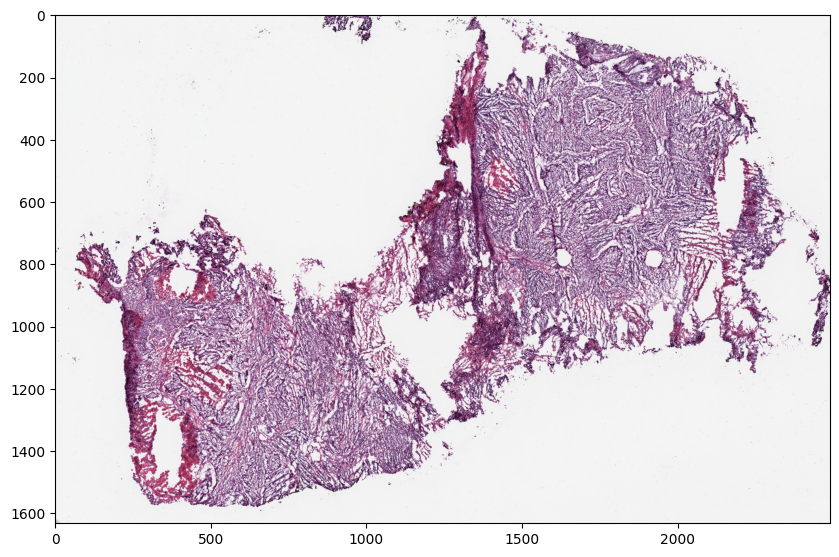

In [ ]:
#if __name__ == "__main__":
  # show_slide(2)
  # slide_info(display_all_properties=True)
  # slide_stats()

  # training_slide_to_image(4)
  # img_path = get_training_image_path(4)
img = open_slide("/content/drive/My Drive/Datasets/Radiomics/new_00232.svs")

region = (0, 0)
level = 2
size = (2489, 1632)
region1 = img.read_region(region, level, size)
plt.figure(figsize=(10, 10))
plt.imshow(region1)

  # slide_to_scaled_pil_image(5)[0].show()
  # singleprocess_training_slides_to_images()
  # multiprocess_training_slides_to_images()

In [ ]:
SCALE_FACTOR = 32
def slide_to_scaled_pil(slide):
  """
  Convert a WSI training slide to a scaled-down PIL image.

  Args:
    slide_number: The slide number.

  Returns:
    Tuple consisting of scaled-down PIL image, original width, original height, new width, and new height.
  """
  #slide_filepath = get_training_slide_path(slide_number)
  #print("Opening Slide #%d: %s" % (slide_number, slide_filepath))
  #slide = open_slide(slide_filepath)

  large_w, large_h = slide.dimensions
  new_w = math.floor(large_w / SCALE_FACTOR)
  new_h = math.floor(large_h / SCALE_FACTOR)
  level = slide.get_best_level_for_downsample(SCALE_FACTOR)
  whole_slide_image = slide.read_region((0, 0), level, slide.level_dimensions[level])
  whole_slide_image = whole_slide_image.convert("RGB")
  img = whole_slide_image.resize((new_w, new_h), PIL.Image.BILINEAR)
  return img, large_w, large_h, new_w, new_h

In [ ]:
pil_img, large_w, large_h, new_w, new_h = slide_to_scaled_pil(img)

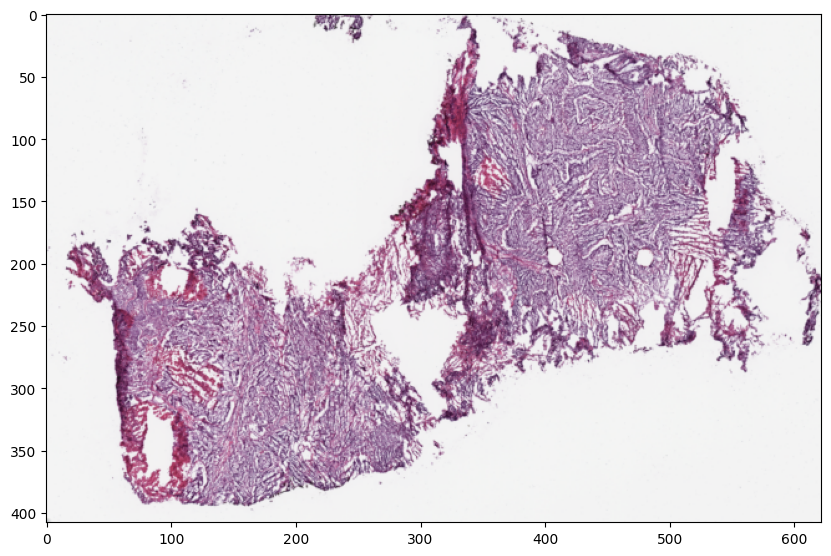

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(pil_img)

In [ ]:
def pil_to_np_rgb(pil_img):
  """
  Convert a PIL Image to a NumPy array.

  Note that RGB PIL (w, h) -> NumPy (h, w, 3).

  Args:
    pil_img: The PIL Image.

  Returns:
    The PIL image converted to a NumPy array.
  """

  rgb = np.asarray(pil_img)
  np_info(rgb, "RGB")
  return rgb

In [ ]:
def slide_to_scaled_np(pil_img):
  """
  Convert a WSI training slide to a scaled-down NumPy image.

  Args:
    slide_number: The slide number.

  Returns:
    Tuple consisting of scaled-down NumPy image, original width, original height, new width, and new height.
  """
  #pil_img, large_w, large_h, new_w, new_h = slide_to_scaled_pil_image(slide_number)
  np_img = pil_to_np_rgb(pil_img)
  return np_img, large_w, large_h, new_w, new_h

In [ ]:
pil_img.show()

In [ ]:
np_img, large_w, large_h, new_w, new_h = slide_to_scaled_np(pil_img)

RGB                  | Type: uint8   Shape: (408, 622, 3)


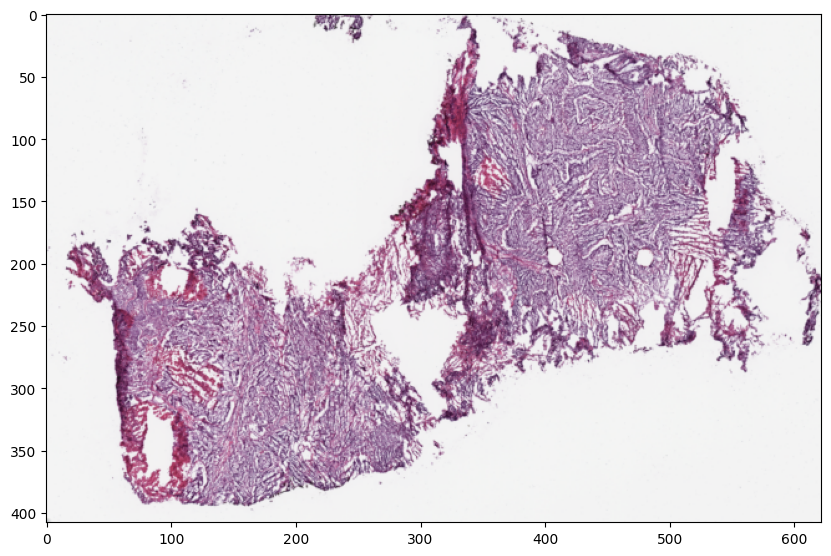

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(np_img)

In [ ]:
np_info(np_img)

NumPy Array          | Type: uint8   Shape: (408, 622, 3)


In [ ]:
pil_img.save("/content/drive/My Drive/Datasets/Radiomics/np_img_test.png")
#pil_img.save("/content/drive/My Drive/Datasets/Radiomics/np_gray_test.png")

In [ ]:
#####---- Filter functions
def filter_rgb_to_grayscale(np_img, output_type="uint8"):
  """
  Convert an RGB NumPy array to a grayscale NumPy array.

  Shape (h, w, c) to (h, w).

  Args:
    np_img: RGB Image as a NumPy array.
    output_type: Type of array to return (float or uint8)

  Returns:
    Grayscale image as NumPy array with shape (h, w).
  """

  # Another common RGB ratio possibility: [0.299, 0.587, 0.114]
  grayscale = np.dot(np_img[..., :3], [0.2125, 0.7154, 0.0721])
  if output_type != "float":
    grayscale = grayscale.astype("uint8")
  np_info(grayscale, "Gray")
  return grayscale


In [ ]:
gray_scale = filter_rgb_to_grayscale(np_img)

Gray                 | Type: uint8   Shape: (408, 622)


In [ ]:
pil_gray = np_to_pil(gray_scale)
pil_gray.save("/content/drive/My Drive/Datasets/Radiomics/np_gray_test.png")

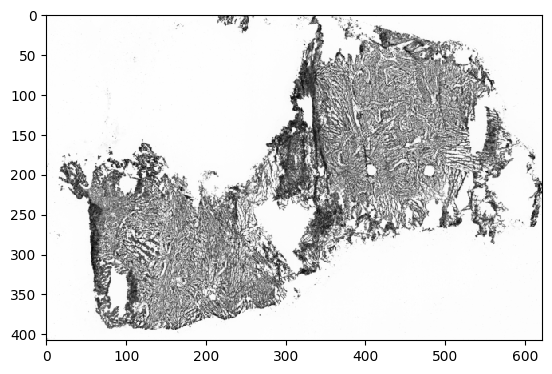

In [ ]:
plt.imshow(gray_scale, interpolation='nearest',cmap='gray')
plt.show()

In [ ]:
def filter_complement(np_img, output_type="uint8"):
  """
  Obtain the complement of an image as a NumPy array.

  Args:
    np_img: Image as a NumPy array.
    type: Type of array to return (float or uint8).

  Returns:
    Complement image as Numpy array.
  """

  if output_type == "float":
    complement = 1.0 - np_img
  else:
    complement = 255 - np_img
  np_info(complement, "Complement")
  return complement

In [ ]:
inv_gray = filter_complement(gray_scale)

Complement           | Type: uint8   Shape: (408, 622)


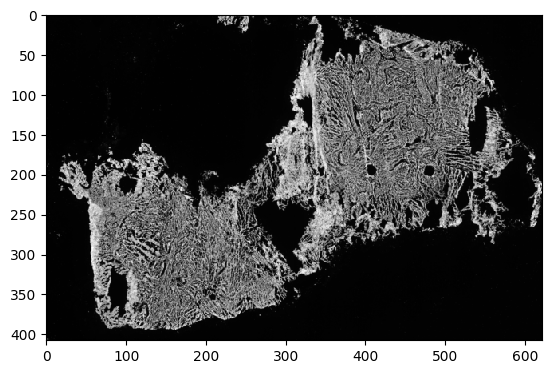

In [ ]:
plt.imshow(inv_gray, interpolation='nearest',cmap='gray')
plt.show()

In [ ]:
'''
from PIL import Image
import numpy as np

test_img = Image.fromarray(inv_gray)
#test_img.show()
plt.imshow(test_img)
'''

'\nfrom PIL import Image\nimport numpy as np\n\ntest_img = Image.fromarray(inv_gray)\n#test_img.show()\nplt.imshow(test_img)\n'

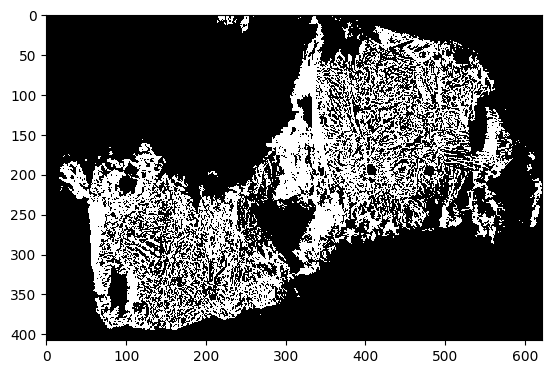

In [ ]:
plt.imshow(threshold_img, interpolation='nearest',cmap='gray')
plt.show()

Masking Procedure:





In [ ]:
'''
img = slide.open_image(img_path)
rgb = util.pil_to_np_rgb(img)
grayscale = filter.filter_rgb_to_grayscale(rgb)
complement = filter.filter_complement(grayscale)
hyst = filter.filter_hysteresis_threshold(complement)
util.display_img(hyst, "Hysteresis Threshold")
'''

'\nimg = slide.open_image(img_path)\nrgb = util.pil_to_np_rgb(img)\ngrayscale = filter.filter_rgb_to_grayscale(rgb)\ncomplement = filter.filter_complement(grayscale)\nhyst = filter.filter_hysteresis_threshold(complement)\nutil.display_img(hyst, "Hysteresis Threshold")\n'

#---- MASKING METHODS

Method I - Basic Thresholding

In [ ]:
#---Method I
# --Basic Thresholding
def filter_threshold(np_img, threshold, output_type="bool"):
  """
  Return mask where a pixel has a value if it exceeds the threshold value.

  Args:
    np_img: Binary image as a NumPy array.
    threshold: The threshold value to exceed.
    output_type: Type of array to return (bool, float, or uint8).

  Returns:
    NumPy array representing a mask where a pixel has a value (T, 1.0, or 255) if the corresponding input array
    pixel exceeds the threshold value.
  """
  #t = Time()
  result = (np_img > threshold)
  if output_type == "bool":
    pass
  elif output_type == "float":
    result = result.astype(float)
  else:
    result = result.astype("uint8") * 255
  #np_info(result, "Threshold", t.elapsed())
  return result

In [ ]:
threshold_img = filter_threshold(inv_gray, threshold=100)

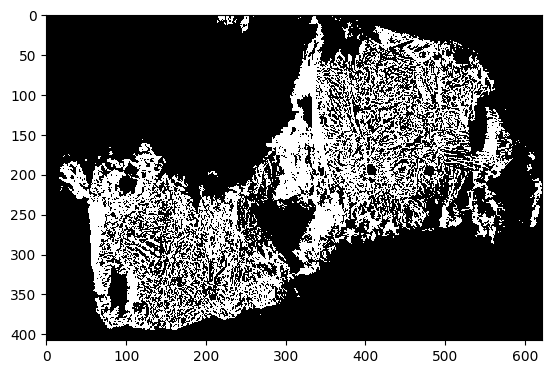

In [ ]:
plt.imshow(threshold_img, interpolation='nearest',cmap='gray')
plt.show()

Method II - *Hysteresis_threshold*

In [ ]:
import skimage.filters as sk_filters
def filter_hysteresis_threshold(np_img, low=50, high=100, output_type="uint8"):
  """
  Apply two-level (hysteresis) threshold to an image as a NumPy array, returning a binary image.

  Args:
    np_img: Image as a NumPy array.
    low: Low threshold.
    high: High threshold.
    output_type: Type of array to return (bool, float, or uint8).

  Returns:
    NumPy array (bool, float, or uint8) where True, 1.0, and 255 represent a pixel above hysteresis threshold.
  """

  hyst = sk_filters.apply_hysteresis_threshold(np_img, low, high)
  if output_type == "bool":
    pass
  elif output_type == "float":
    hyst = hyst.astype(float)
  else:
    hyst = (255 * hyst).astype("uint8")
  #np_info(hyst, "Hysteresis Threshold")
  return hyst

In [ ]:
hyst_img = filter_hysteresis_threshold(inv_gray)

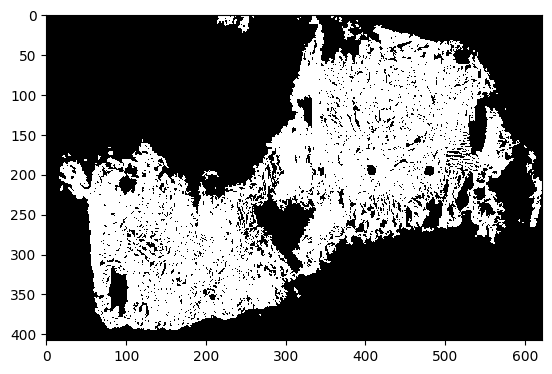

In [ ]:
plt.imshow(hyst_img, interpolation='nearest',cmap='gray')
plt.show()

Method III - Otsu Threshold Filter

In [ ]:
# import skimage.filters as sk_filters
def filter_otsu_threshold(np_img, output_type="uint8"):
  """
  Compute Otsu threshold on image as a NumPy array and return binary image based on pixels above threshold.

  Args:
    np_img: Image as a NumPy array.
    output_type: Type of array to return (bool, float, or uint8).

  Returns:
    NumPy array (bool, float, or uint8) where True, 1.0, and 255 represent a pixel above Otsu threshold.
  """

  otsu_thresh_value = sk_filters.threshold_otsu(np_img)
  otsu = (np_img > otsu_thresh_value)
  if output_type == "bool":
    pass
  elif output_type == "float":
    otsu = otsu.astype(float)
  else:
    otsu = otsu.astype("uint8") * 255
  #np_info(otsu, "Otsu Threshold")
  return otsu

In [ ]:
otsu_img = filter_otsu_threshold(inv_gray)

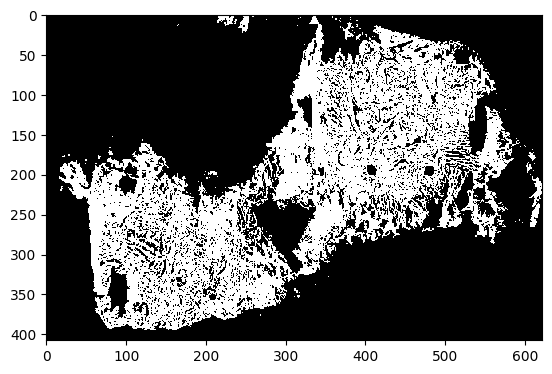

In [ ]:
plt.imshow(otsu_img, interpolation='nearest',cmap='gray')
plt.show()

Convert Numpy Images to PIL

In [ ]:
def np_to_pil(np_img):
  """
  Convert a NumPy array to a PIL Image.

  Args:
    np_img: The image represented as a NumPy array.

  Returns:
     The NumPy array converted to a PIL Image.
  """
  if np_img.dtype == "bool":
    np_img = np_img.astype("uint8") * 255
  elif np_img.dtype == "float64":
    np_img = (np_img * 255).astype("uint8")
  return Image.fromarray(np_img)

In [ ]:
pil_mask_thr = np_to_pil(threshold_img)

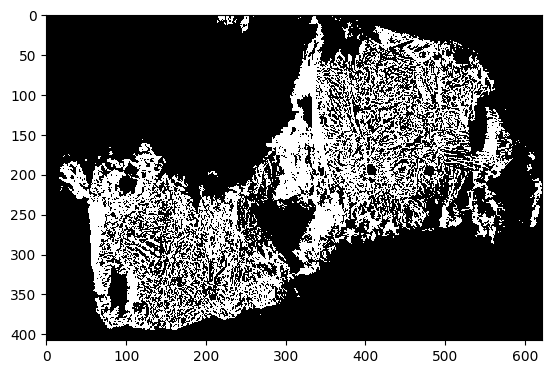

In [ ]:
plt.imshow(pil_mask_thr, interpolation='nearest',cmap='gray')
plt.show()

In [ ]:
pil_mask_thr.save("/content/drive/My Drive/Datasets/Radiomics/pil_mask_test.png")

Load Image and Mask files

In [ ]:
pil_img_1 = open_image("/content/drive/My Drive/Datasets/Radiomics/np_img_test.png")
pil_mask_1 = open_image("/content/drive/My Drive/Datasets/Radiomics/pil_mask_test.png")
pil_gray_1 = open_image("/content/drive/My Drive/Datasets/Radiomics/np_gray_test.png")

Convert Image and Mask to Numpy files

In [ ]:
np_img_1 = pil_to_np_rgb(pil_img_1)
np_mask_1 = pil_to_np_rgb(pil_mask_1)
np_gray_1 = pil_to_np_rgb(pil_gray_1)


RGB                  | Type: uint8   Shape: (408, 622, 3)
RGB                  | Type: uint8   Shape: (408, 622)
RGB                  | Type: uint8   Shape: (408, 622)


RADIOMICS

In [ ]:
!pip install pyradiomics
import os  # needed navigate the system to get the input data

from radiomics import featureextractor  # This module is used for interaction with pyradiomics

In [ ]:
# special functions for using pyradiomics
from SimpleITK import GetImageFromArray
import radiomics
from radiomics.featureextractor import RadiomicsFeatureExtractor # This module is used for interaction with pyradiomic
import logging
logging.getLogger('radiomics').setLevel(logging.CRITICAL + 1)  # this tool makes a whole TON of log noise

SET UP PYRADIOMICS CODE

Instantiate the Extractor

In [ ]:
# Instantiate the extractor
texture_extractor = RadiomicsFeatureExtractor(verbose=False)
texture_extractor.disableAllFeatures()
_text_feat = {ckey: [] for ckey in texture_extractor.featureClassNames}
texture_extractor.enableFeaturesByName(**_text_feat)

print('Extraction parameters:\n\t', texture_extractor.settings)
print('Enabled filters:\n\t', texture_extractor.enabledImagetypes)
print('Enabled features:\n\t', texture_extractor.enabledFeatures)

Extraction parameters:
	 {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True, 'verbose': False}
Enabled filters:
	 {'Original': {}}
Enabled features:
	 {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': [], 'shape2D': []}


Load Libraries

In [ ]:
import numpy as np # for manipulating 3d images
import pandas as pd # for reading and writing tables
#import h5py # for reading the image files
import skimage # for image processing and visualizations
import sklearn # for machine learning and statistical models
import os # help us load files and deal with paths
from pathlib import Path # help manage files

# plot setup code
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["figure.dpi"] = 125
plt.rcParams["font.size"] = 14
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.style.use('ggplot')
sns.set_style("whitegrid", {'axes.grid': False})

CALCULATE RADIOMIC FEATURES

In [ ]:
np_info(np_gray_1)
np_info(np_mask_1)

#results = texture_extractor.execute(GetImageFromArray(np_img_1),GetImageFromArray((np_mask_1>0).astype(np.uint8)))

NumPy Array          | Type: uint8   Shape: (408, 622)
NumPy Array          | Type: uint8   Shape: (408, 622)


In [ ]:
results = texture_extractor.execute(GetImageFromArray(np_gray_1),
                            GetImageFromArray((np_mask_1>0).astype(np.uint8)))

In [ ]:
print(type(results))

<class 'collections.OrderedDict'>


Display Results

In [ ]:
data1 = pd.DataFrame([results])
data1b = pd.DataFrame([results2])

In [ ]:
data1.to_csv("/content/drive/My Drive/Datasets/Radiomics/dict.csv")

In [ ]:
print(data1)

Alternative Approach

In [ ]:
np_info(inv_gray)
np_info(np_mask_1)

NumPy Array          | Type: uint8   Shape: (408, 622)
NumPy Array          | Type: uint8   Shape: (408, 622)


In [ ]:
results2 = texture_extractor.execute(GetImageFromArray(inv_gray),
                            GetImageFromArray((np_mask_1>0).astype(np.uint8)))

In [ ]:
print(results)

OrderedDict([('diagnostics_Versions_PyRadiomics', 'v3.0.1'), ('diagnostics_Versions_Numpy', '1.23.5'), ('diagnostics_Versions_SimpleITK', '2.3.0'), ('diagnostics_Versions_PyWavelet', '1.4.1'), ('diagnostics_Versions_Python', '3.10.12'), ('diagnostics_Configuration_Settings', {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True, 'verbose': False}), ('diagnostics_Configuration_EnabledImageTypes', {'Original': {}}), ('diagnostics_Image-original_Hash', 'f75578c02716ed0c38d811e0a22421c372dad175'), ('diagnostics_Image-original_Dimensionality', '2D'), ('diagnostics_Image-original_Spacing', (1.0, 1.0)), ('diagnostics_Image-original_Size', (622, 408)), ('diagnostics_Image-original_Mean', 202.42142677006493), ('diagnosti

Convert Results (dict datatype) to Dataframe

In [ ]:
data2 = data1.append(results2, ignore_index=True)

<ipython-input-142-238ff142398c>:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data2 = data1.append(results2, ignore_index=True)


In [ ]:
data2.to_csv("/content/drive/My Drive/Datasets/Radiomics/dict2.csv")

NameError: ignored

In [ ]:
#new_row = pd.DataFrame({'Courses':'Hyperion', 'Fee':24000, 'Duration':'55days', 'Discount':1800}, index=[0])
df2 = pd.concat([data1b,data1.loc[:]]).reset_index(drop=True)
print (df2)

  diagnostics_Versions_PyRadiomics diagnostics_Versions_Numpy  \
0                           v3.0.1                     1.23.5   
1                           v3.0.1                     1.23.5   

  diagnostics_Versions_SimpleITK diagnostics_Versions_PyWavelet  \
0                          2.3.0                          1.4.1   
1                          2.3.0                          1.4.1   

  diagnostics_Versions_Python  \
0                     3.10.12   
1                     3.10.12   

                  diagnostics_Configuration_Settings  \
0  {'minimumROIDimensions': 2, 'minimumROISize': ...   
1  {'minimumROIDimensions': 2, 'minimumROISize': ...   

  diagnostics_Configuration_EnabledImageTypes  \
0                            {'Original': {}}   
1                            {'Original': {}}   

            diagnostics_Image-original_Hash  \
0  730ea2c35f77cf6526d92f0435378c524a689272   
1  f75578c02716ed0c38d811e0a22421c372dad175   

  diagnostics_Image-original_Dimensionality

In [ ]:
df2.to_csv("/content/drive/My Drive/Datasets/Radiomics/dict3_concat.csv")